In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.preprocessing import MinMaxScaler
import joblib
import os

# Cấu hình hiển thị
%matplotlib inline

# ==========================================
# CẤU HÌNH
# ==========================================
INPUT_FILE = "../../data/processed/train_data_ready.csv" # Vẫn dùng file cũ, nhưng tí nữa mình chỉ lấy cột Gold
MODEL_FILE = "../../model/best_model_gold_only.keras"    # Lưu tên khác để không đè lên model cũ
SCALER_FILE = "../../model/scaler_gold_only.pkl"         # Lưu thước đo riêng cho Vàng

# Cửa sổ nhìn lại (Look-back)
WINDOW_SIZE = 60 

print(f"✅ Đã sẵn sàng! Tensorflow version: {tf.__version__}")

✅ Đã sẵn sàng! Tensorflow version: 2.20.0


In [11]:
# 1. Đọc dữ liệu
if not os.path.exists(INPUT_FILE):
    print(f"❌ Lỗi: Không thấy file {INPUT_FILE}")
else:
    df = pd.read_csv(INPUT_FILE)
    
    # --- QUAN TRỌNG: CHỈ LẤY CỘT GOLD ---
    # Dùng 2 dấu ngoặc vuông [['Gold']] để nó vẫn là DataFrame (bảng), không bị biến thành Series
    df_gold = df[['Gold']] 
    
    print("Dataset gốc (Nhiều cột):", df.shape)
    print("Dataset sau khi lọc (Chỉ còn Vàng):", df_gold.shape)
    display(df_gold.head())

    # Chuyển thành mảng Numpy để tính toán
    data_values = df_gold.values

Dataset gốc (Nhiều cột): (7637, 12)
Dataset sau khi lọc (Chỉ còn Vàng): (7637, 1)


,Gold
0,0.057141
1,0.058175
2,0.058421
3,0.058864
4,0.059947


In [12]:
# 1. Chuẩn hóa (Bắt buộc với LSTM)
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data_values)

# Lưu lại Scaler này để dùng cho Demo sau này
if not os.path.exists("model"):
    os.makedirs("model")
joblib.dump(scaler, SCALER_FILE)
print(f"✅ Đã lưu Scaler riêng cho Vàng tại: {SCALER_FILE}")

# 2. Hàm cắt dữ liệu (Sliding Window)
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        # Input: 60 giá vàng quá khứ
        X.append(data[i : i + window_size])
        # Output: Giá vàng thứ 61
        y.append(data[i + window_size, 0]) # Index 0 vì chỉ có 1 cột
    return np.array(X), np.array(y)

# 3. Áp dụng
X, y = create_sequences(data_scaled, WINDOW_SIZE)

print(f"\n✂️ Kích thước dữ liệu sau khi cắt:")
print(f"   - Input (X): {X.shape} (Mẫu, 60 giờ, 1 đặc trưng)")
print(f"   - Label (y): {y.shape}")

✅ Đã lưu Scaler riêng cho Vàng tại: ../../model/scaler_gold_only.pkl

✂️ Kích thước dữ liệu sau khi cắt:
   - Input (X): (7577, 60, 1) (Mẫu, 60 giờ, 1 đặc trưng)
   - Label (y): (7577,)


In [13]:
split_idx = int(len(X) * 0.8)

X_train, X_val = X[:split_idx], X[split_idx:]
y_train, y_val = y[:split_idx], y[split_idx:]

print(f"📊 Train set: {len(X_train)} mẫu")
print(f"📊 Val set:   {len(X_val)} mẫu")

📊 Train set: 6061 mẫu
📊 Val set:   1516 mẫu


In [14]:
model = Sequential()

# Layer 1: LSTM
# input_shape = (60, 1) -> Số 1 ở cuối nghĩa là chỉ có 1 đặc trưng (Giá Vàng)
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))

# Layer 2: LSTM
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

# Output
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

# --- TRAINING ---
checkpoint = ModelCheckpoint(MODEL_FILE, monitor='val_loss', save_best_only=True, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("\n🚀 Bắt đầu train (Gold Only)...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[checkpoint, early_stop],
    verbose=1
)

c:\Users\minam\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)


🚀 Bắt đầu train (Gold Only)...
Epoch 1/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.0102
Epoch 1: val_loss improved from None to 0.00038, saving model to ../../model/best_model_gold_only.keras
190/190 ━━━━━━━━━━━━━━━━━━━━ 26s 88ms/step - loss: 0.0033 - val_loss: 3.8196e-04
Epoch 2/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 8.8070e-04
Epoch 2: val_loss improved from 0.00038 to 0.00027, saving model to ../../model/best_model_gold_only.keras
190/190 ━━━━━━━━━━━━━━━━━━━━ 16s 63ms/step - loss: 8.2824e-04 - val_loss: 2.6564e-04
Epoch 3/50
189/190 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 8.3729e-04
Epoch 3: val_loss did not improve from 0.00027
190/190 ━━━━━━━━━━━━━━━━━━━━ 20s 107ms/step - loss: 7.5477e-04 - val_loss: 5.3708e-04
Epoch 4/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 6.4674e-04
Epoch 4: val_loss did not improve from 0.00027
190/190 ━━━━━━━━━━━━━━━━━━━━ 23s 120ms/step - loss: 6.4464e-04 - val_loss: 8.2724e-04
Epoch 5/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 

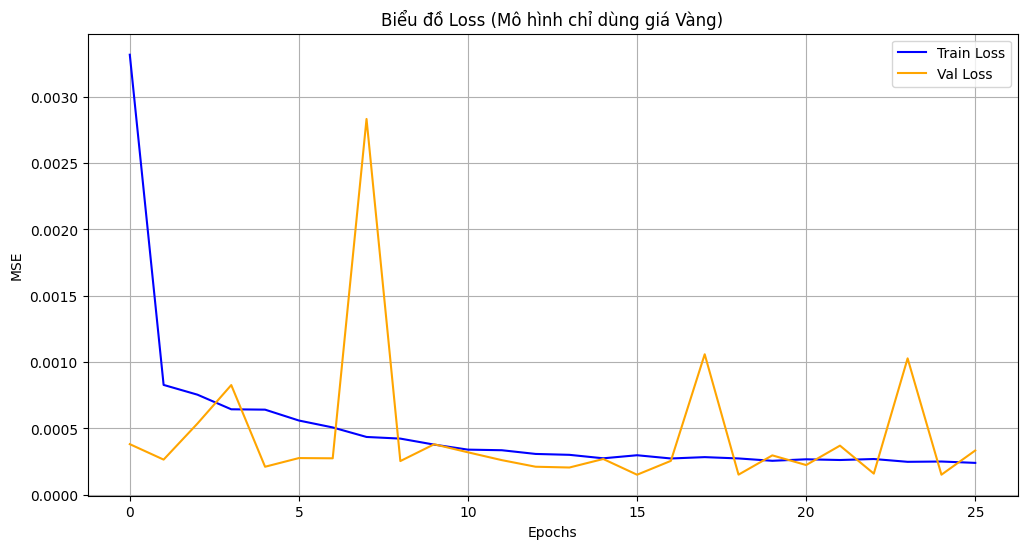

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.title('Biểu đồ Loss (Mô hình chỉ dùng giá Vàng)')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.show()

48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step


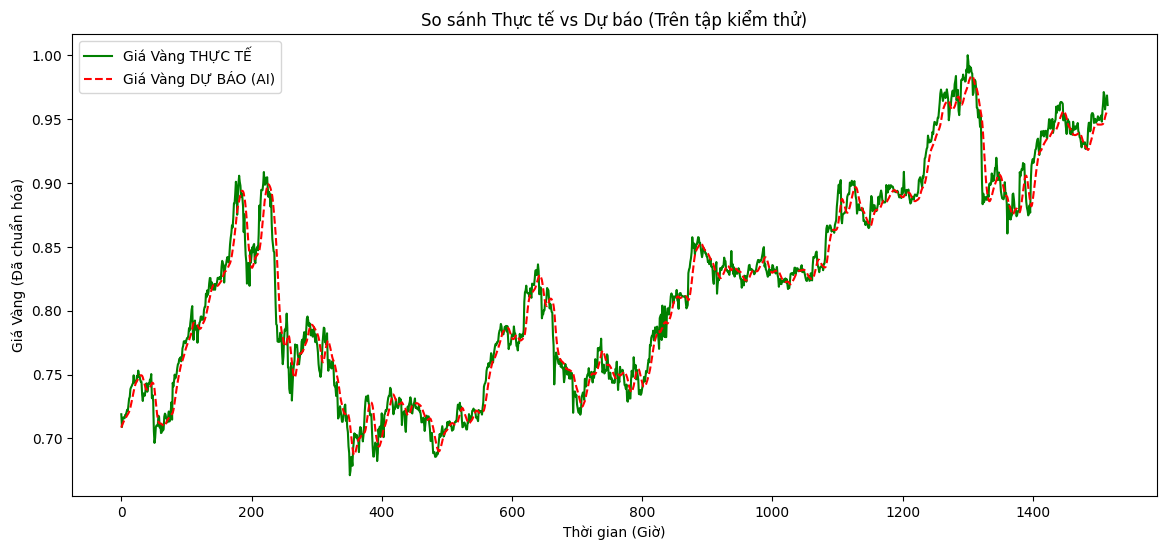

In [16]:
# 1. Dự báo trên tập Validation
y_pred = model.predict(X_val)

# 2. Đảo ngược chuẩn hóa (Inverse Transform) để ra giá USD thật
# Vì scaler train trên data 2 chiều, ta cần trick nhỏ để inverse
y_val_real = scaler.inverse_transform(y_val.reshape(-1, 1))
y_pred_real = scaler.inverse_transform(y_pred)

# 3. Vẽ biểu đồ so sánh
plt.figure(figsize=(14, 6))
plt.plot(y_val_real, label='Giá Vàng THỰC TẾ', color='green')
plt.plot(y_pred_real, label='Giá Vàng DỰ BÁO (AI)', color='red', linestyle='--')
plt.title('So sánh Thực tế vs Dự báo (Trên tập kiểm thử)')
plt.xlabel('Thời gian (Giờ)')
plt.ylabel('Giá Vàng (Đã chuẩn hóa)') # Vì dữ liệu gốc của bạn đã scale sẵn rồi
plt.legend()
plt.show()